In [2]:
#!/g/data/xp65/public/apps/med_conda_scripts/analysis3-25.07.d/bin/python3
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime
import xesmf as xe
import re

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)

dataset = 'barra-r2'
ct = 'low'
year = 2020

if dataset == 'himawari':
    resolution = 'instant'
else:
    resolution = 'hourly'

In [12]:
ds = xr.open_zarr("/g/data/su28/himawari-ahi/cloud/ct/aus_regional_domain/S_NWC_CT_HIMA08_HIMA-N-NR.zarr/")

i=0
month='01'

ds_ghi = read_dataset(
    dataset=dataset,
    resolution=resolution,
    date=f'{year}-{month}'
)

if i == 0:
    ds = ds.sel(
        lat=slice(ds_ghi.lat.max(), ds_ghi.lat.min()),
        lon=slice(ds_ghi.lon.min(), ds_ghi.lon.max())
    )
him_ct = ds.ct.sel(time=f'{year}-{month}')

if dataset == 'himawari':
    # ALIGN DATASETS
    ds_ghi = ds_ghi.interp(
        lat=him_ct.lat,
        lon=him_ct.lon,
        method='linear'
    )
    start = ds_ghi.time.min().item()
    end = ds_ghi.time.max().item()
    # fill missing overnight time steps
    full_time = pd.date_range(
        start=start,
        end=end,
        freq="10min"
    )
    ds_ghi = ds_ghi.reindex(time=full_time, fill_value=0)
elif dataset == 'barra-r2':
    # ALIGN DATASETS
    him_ct = him_ct.interp(
        lat=ds_ghi.lat,
        lon=ds_ghi.lon,
        method='nearest'
    )

# trim ends
min_time = him_ct.time.min()
max_time = ds_ghi.time.max()
t_range = slice(min_time, max_time)
him_ct = him_ct.sel(time=t_range)
ds_ghi = ds_ghi.sel(time=t_range)

# ds_ghi_times = ds_ghi.sel(time=him_ct.time)
him_ct_time = him_ct.sel(time=ds_ghi.time)

In [13]:
him_ct_time

<xarray.DataArray 'ct' (time: 744, lat: 314, lon: 403)> Size: 377MB
dask.array<getitem, shape=(744, 314, 403), dtype=float32, chunksize=(22, 314, 403), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-01-01T00:30:00 ... 2020-01-31T23:...
  * lat      (lat) float64 3kB -44.44 -44.33 -44.22 ... -10.23 -10.12 -10.01
  * lon      (lon) float64 3kB 112.0 112.1 112.2 112.3 ... 156.0 156.1 156.2
    crs      int32 4B 0
Attributes:
    ancillary_variables:  ct_status_flag ct_conditions ct_quality ct_pal
    comment:              1:  Cloud-free land; 2:  Cloud-free sea; 3:  Snow o...
    flag_meanings:        Cloud-free_land Cloud-free_sea Snow_over_land Sea_i...
    flag_values:          [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    long_name:            NWC GEO CT Cloud Type
    valid_range:          [1, 15]

In [1]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec

import zarr
import xesmf as xe
import re

from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import cartopy.feature as cft
import cmocean as cmo
import matplotlib as mpl
import matplotlib.ticker as mticker

import sys
sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
from cloud_types import plot_himawari_ct

from dask.distributed import Client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
client = Client(
    n_workers=12,
    threads_per_worker=1
)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 12
Total threads: 12,Total memory: 7.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37239,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43449,Total threads: 1
Dashboard: /proxy/40435/status,Memory: 597.33 MiB
Nanny: tcp://127.0.0.1:43731,


2026-01-15 17:31:58,247 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:45507 (pid=948307) exceeded 95% memory budget. Restarting...
2026-01-15 17:31:58,276 - distributed.nanny - WARNING - Restarting worker


# File Paths

In [3]:
HIMAWARI = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/v1.1')

ERA5 = Path('/g/data/rt52/era5/single-levels/')

BARRA = Path('/g/data/ob53/BARRA2/output/reanalysis/')

BARRA_R2 = BARRA / "AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/"

BARRA_C2 = BARRA / "AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1"

CERES = Path('/g/data/er8/users/cd3022/ceres-ebaf/CERES_EBAF_Ed4.2.1_Subset_201503-202504.nc')

# Date to Investigate

In [4]:
year = 2024
month = 1
day = 12
hour = 2

# GHI

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


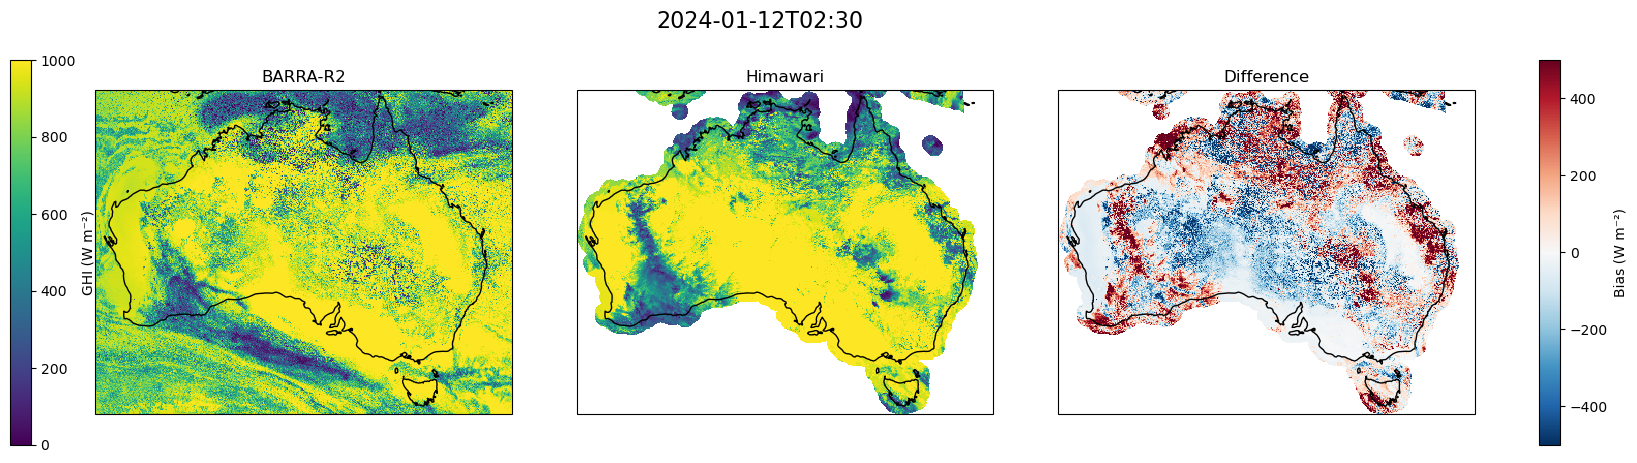

In [5]:
# OPEN DATASETS
himawari = xr.open_dataset(f'{HIMAWARI}/{year}/{month:02d}/{day:02d}/IDE00326.{year}{month:02d}{day:02d}{hour:02d}30.nc', engine='h5netcdf')
bar_name = f'rsds_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_{year}{month:02d}-{year}{month:02d}.nc'
barra = xr.open_dataset(f'{BARRA_R2}/rsds/latest/{bar_name}', engine='h5netcdf')

# RESTRICT BARRA REGION TO HIMAWARI
barra = barra.sel(
    lat=slice(himawari.latitude.min(), himawari.latitude.max()),
    lon=slice(himawari.longitude.min(), himawari.longitude.max())
)

# SET DATE
date = f'{year}-{month:02d}-{day:02d}T{hour:02d}:30'

# SELECT DATA FOR PLOTTING
barra_data = barra.rsds.sel(time=date)
him_data = himawari.surface_global_irradiance.isel(time=0)
him_data = him_data.interp( latitude=barra.lat, longitude=barra.lon, method='linear' )

# START PLOTTING
fig = plt.figure(figsize=(20, 5))

# SET GRID FOR SUBPLOTS
gs = GridSpec(
    nrows=1, ncols=5,
    width_ratios=[0.05, 1, 1, 1, 0.05],
    wspace=0.25
)

# Map axes (same size)
ax0 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(gs[2], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[3], projection=ccrs.PlateCarree())

# Colorbar axes (thin)
cax_left  = fig.add_subplot(gs[0])
cax_right = fig.add_subplot(gs[4])

# PLOT DATA ONTO AXES
mesh_bar = ax0.pcolormesh(
    barra.lon, barra.lat, barra_data,
    cmap='viridis', vmin=0, vmax=1000,
    shading='auto', transform=ccrs.PlateCarree()
)

mesh_him = ax1.pcolormesh(
    him_data.lon, him_data.lat, him_data,
    cmap='viridis', vmin=0, vmax=1000,
    shading='auto', transform=ccrs.PlateCarree()
)

diff = barra_data - him_data
mesh_dif = ax2.pcolormesh(
    him_data.lon, him_data.lat, diff,
    cmap='RdBu_r', vmin=-500, vmax=500,
    shading='auto', transform=ccrs.PlateCarree()
)

# Titles
ax0.set_title('BARRA-R2')
ax1.set_title('Himawari')
ax2.set_title('Difference')

# Coastlines
for ax in (ax0, ax1, ax2):
    ax.coastlines()

# Colorbars (no resizing!)
cbar_abs = fig.colorbar(mesh_bar, cax=cax_left)
cbar_abs.set_label('GHI (W m⁻²)')

cbar_dif = fig.colorbar(mesh_dif, cax=cax_right)
cbar_dif.set_label('Bias (W m⁻²)')

fig.suptitle(date, fontsize=16)

plt.savefig(
    f'/home/548/cd3022/figures/Irradiance_comparisons/time_slices/{date}.png',
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

# LWP/IWP

In [6]:
# LOAD BARRA-R2 DATA
bar_name = f'clwvi_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_{year}{month:02d}-{year}{month:02d}.nc'
barra_lwp = xr.open_dataset(f'{BARRA_R2}/clwvi/latest/{bar_name}', engine='h5netcdf')
barra_lwp = barra_lwp.sel(
    lat=slice(himawari.latitude.min(), himawari.latitude.max()),
    lon=slice(himawari.longitude.min(), himawari.longitude.max())
)

bar_name = f'clivi_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_{year}{month:02d}-{year}{month:02d}.nc'
barra_iwp = xr.open_dataset(f'{BARRA_R2}/clivi/latest/{bar_name}', engine='h5netcdf')
barra_iwp = barra_iwp.sel(
    lat=slice(himawari.latitude.min(), himawari.latitude.max()),
    lon=slice(himawari.longitude.min(), himawari.longitude.max())
)

In [7]:
# ANCILLARY FILE FOR HIMAWARI CMIC
ancil = xr.open_dataset('/g/data/ra22/satellite-products/arc/obs/himawari-ahi/fldk/latest/ancillary/00000000000000-P1S-ABOM_GEOM_SENSOR-PRJ_GEOS141_2000-HIMAWARI8-AHI.nc')
ancil = ancil.isel(time=0)

In [8]:
# LOAD HIMAWARI CMIC DATA
file_path = Path(f'/g/data/rv74/satellite-products/arc/der/himawari-ahi/cloud/cmic/latest/{year}/{month:02d}/{day}/')
files = [f for f in file_path.glob(f"*{year}{month:02d}{day:02d}T{hour:02d}00*.nc")]

# Pre-load ancillary coordinates once
lat_ancil = ancil.lat.data
lon_ancil = ancil.lon.data

# DATETIME IS NOT IN NETCDF FILE, HAS TO BE ADDED WHILE OPENING FILE FROM THE FILE NAME
def make_preprocess_func(filepaths):
    def _preprocess(ds, file_idx):
        f = filepaths[file_idx]
        match = re.search(r"_(\d{8}T\d{6})Z\.nc$", f.name)
        time = pd.to_datetime(match.group(1), format="%Y%m%dT%H%M%S")
        ds = ds.assign_coords(
            time=time,
            lat=(("ny", "nx"), lat_ancil),
            lon=(("ny", "nx"), lon_ancil)
        )
        ds["cmic_lwp"] = ds["cmic_lwp"].fillna(0)
        return ds

    def preprocess_with_index(i, ds):
        return _preprocess(ds, i)

    return preprocess_with_index

preprocess_func = make_preprocess_func(files)

# OPEN THE FILES
datasets = []
for i, f in enumerate(files):
    ds = xr.open_dataset(f, engine='h5netcdf', chunks='auto')
    ds = preprocess_func(i, ds)
    datasets.append(ds)
him_cmic = xr.concat(datasets, dim="time")

# SELECT JUST THE DATA OF INTEREST
him_cmic_slice = him_cmic.sel(ny=slice(-1.1e6, -4.25e6), nx=slice(-3e6, 1.3e6))
him_wp = him_cmic_slice[['cmic_lwp', 'cmic_iwp']]

# Define region bounds
lat_min, lat_max = -44.5, -10.0
lon_min, lon_max = 112.0, 156.126

# Define target 1D grid
target = xr.Dataset({
    "lat": (["lat"], np.linspace(lat_min, lat_max, barra_lwp.lat.shape[0])),
    "lon": (["lon"], np.linspace(lon_min, lon_max, barra_lwp.lon.shape[0])),
})

regridder = xe.Regridder(him_wp, target, "bilinear")
him_wp_reg = regridder(him_wp)

him_wp_reg = him_wp_reg.interp(
    lat=barra_lwp.lat,
    lon=barra_lwp.lon,
    method='linear'
)

# LOAD DATA TO PREVENT LATER DASK ISSUES
him_wp_reg = him_wp_reg.load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 11.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-01-15 17:31:58,201 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 484.23 MiB -- Worker memory limit: 597.33 MiB
2026-01-15 17:31:58,206 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memor

Text(0.5, 0.98, '2024-01-12T02:00')

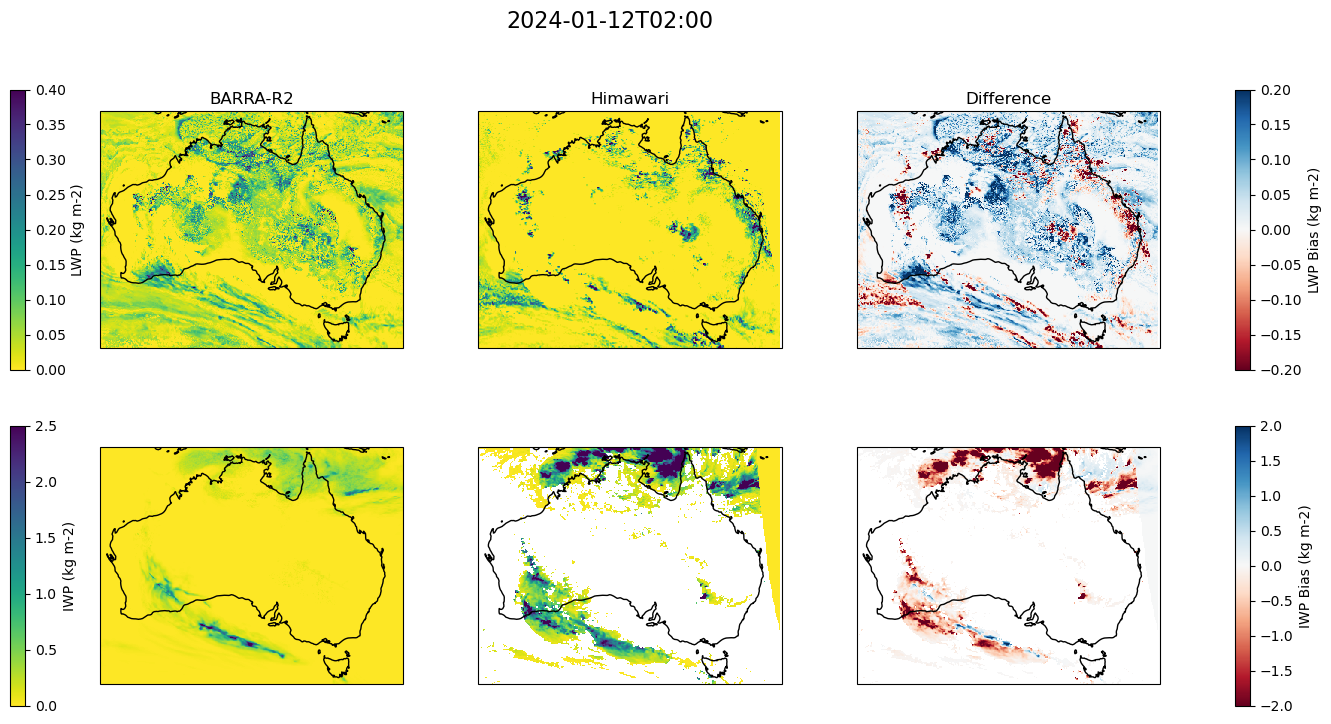

In [9]:
# SET THE DATE
date = f'{year}-{month:02d}-{day:02d}T{hour:02d}:00'

# SELECT DATA TO PLOT
barra_data_liq = barra_lwp.clwvi.sel(time=date)
him_data_liq = him_wp_reg.isel(time=0).cmic_lwp
barra_data_ice = barra_iwp.clivi.sel(time=date)
him_data_ice = him_wp_reg.isel(time=0).cmic_iwp

# START PLOTTING
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(
    nrows=2, ncols=5,
    width_ratios=[0.05, 1, 1, 1, 0.05],
    wspace=0.4
)

# Map axes (same size)
ax0 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(gs[0,2], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0,3], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[1,2], projection=ccrs.PlateCarree())
ax5 = fig.add_subplot(gs[1,3], projection=ccrs.PlateCarree())

# Colorbar axes (thin)
cax_left_up  = fig.add_subplot(gs[0,0])
cax_right_up = fig.add_subplot(gs[0,4])
cax_left_down  = fig.add_subplot(gs[1,0])
cax_right_down = fig.add_subplot(gs[1,4])

# PLOT DATA ONTO AXES
mesh_bar_liq = ax0.pcolormesh(
    barra_data_liq.lon, barra_data_liq.lat, barra_data_liq,
    cmap='viridis_r', vmin=0, vmax=0.4,
    shading='auto', transform=ccrs.PlateCarree()
)

mesh_him_liq = ax1.pcolormesh(
    him_data_liq.lon, him_data_liq.lat, him_data_liq,
    cmap='viridis_r', vmin=0, vmax=0.4,
    shading='auto', transform=ccrs.PlateCarree()
)

diff_liq = barra_data_liq - him_data_liq
mesh_dif_liq = ax2.pcolormesh(
    diff_liq.lon, diff_liq.lat, diff_liq,
    cmap='RdBu', vmin=-0.2, vmax=0.2,
    shading='auto', transform=ccrs.PlateCarree()
)

mesh_bar_ice = ax3.pcolormesh(
    barra_data_ice.lon, barra_data_ice.lat, barra_data_ice,
    cmap='viridis_r', vmin=0, vmax=2.5,
    shading='auto', transform=ccrs.PlateCarree()
)

mesh_him_liq = ax4.pcolormesh(
    him_data_ice.lon, him_data_ice.lat, him_data_ice,
    cmap='viridis_r', vmin=0, vmax=2.5,
    shading='auto', transform=ccrs.PlateCarree()
)

diff_ice = barra_data_ice - him_data_ice
mesh_dif_ice = ax5.pcolormesh(
    diff_ice.lon, diff_ice.lat, diff_ice,
    cmap='RdBu', vmin=-2, vmax=2,
    shading='auto', transform=ccrs.PlateCarree()
)

# Titles
ax0.set_title('BARRA-R2')
ax1.set_title('Himawari')
ax2.set_title('Difference')

# Coastlines
for ax in (ax0, ax1, ax2, ax3, ax4, ax5):
    ax.coastlines()

# Colorbars (no resizing!)
cbar_abs_liq = fig.colorbar(mesh_bar_liq, cax=cax_left_up)
cbar_abs_liq.set_label('LWP (kg m-2)')

cbar_dif_liq = fig.colorbar(mesh_dif_liq, cax=cax_right_up)
cbar_dif_liq.set_label('LWP Bias (kg m-2)')

cbar_abs_ice = fig.colorbar(mesh_bar_ice, cax=cax_left_down)
cbar_abs_ice.set_label('IWP (kg m-2)')

cbar_dif_ice = fig.colorbar(mesh_dif_ice, cax=cax_right_down)
cbar_dif_ice.set_label('IWP Bias (kg m-2)')

fig.suptitle(date, fontsize=16)

# plt.savefig(
#     f'/home/548/cd3022/figures/Irradiance_comparisons/time_slices/{date}.png',
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.02
# )

# Cloud Types

1: Cloud-free land
2: Cloud-free sea
3: Snow over land
4: Sea ice
5: Very low clouds
6: Low clouds
7: Mid-level clouds
8: High opaque clouds
9: Very high opaque clouds
10: Fractional clouds
11: High semitransparent thin clouds
12: High semitransparent moderately thick clouds
13: High semitransparent thick clouds
14: High semitransparent above low or medium clouds


2026-01-15 17:32:11,132 - distributed.worker.memory - WARNING - Worker is at 84% memory usage. Pausing worker.  Process memory: 505.17 MiB -- Worker memory limit: 597.33 MiB
2026-01-15 17:32:11,242 - distributed.worker.memory - WARNING - Worker is at 48% memory usage. Resuming worker. Process memory: 288.49 MiB -- Worker memory limit: 597.33 MiB


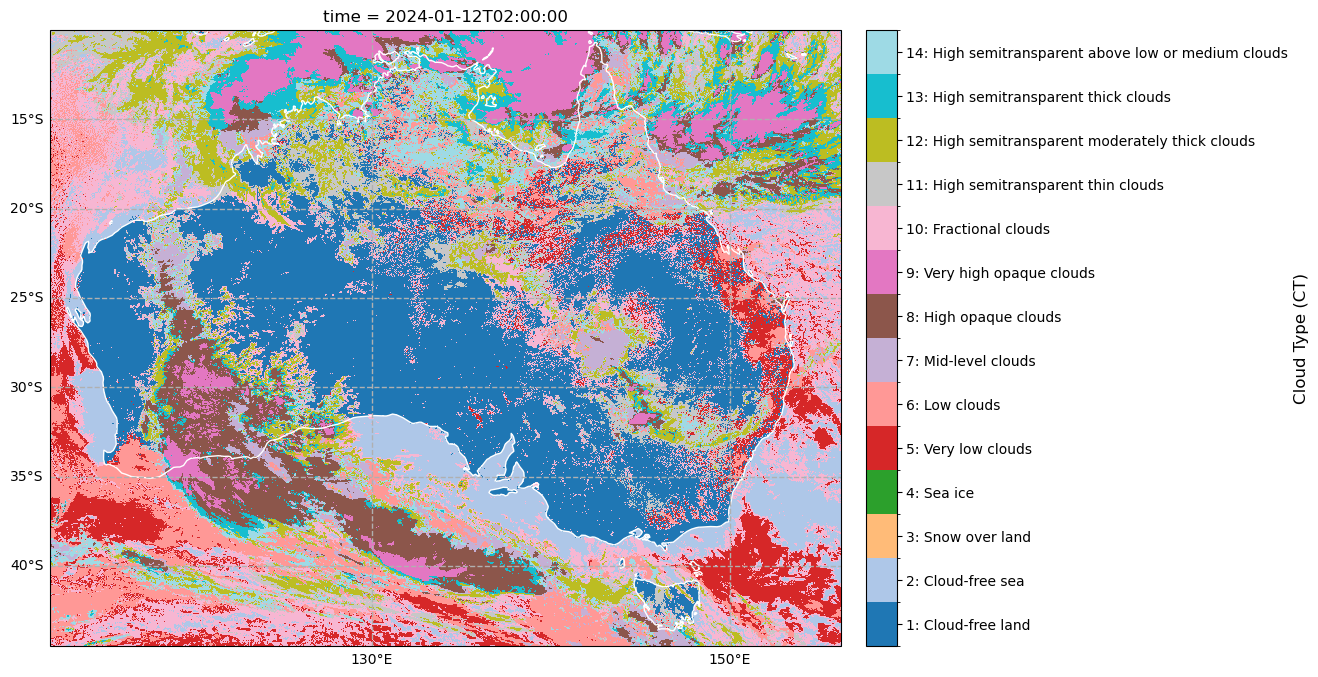

In [10]:
plot_himawari_ct(date)

# Coarsen

In [11]:
barra_data = barra.rsds.sel(time=date)
him_data = himawari.surface_global_irradiance.isel(time=0)
him_data = him_data.interp( latitude=barra.lat, longitude=barra.lon, method='linear' )

# Coarsen both datasets to give fairer spatial comparison
coarse_factor = 4
barra_data_coarse = barra_data.coarsen(lat=coarse_factor, lon=coarse_factor, boundary='trim').mean()
him_data_coarse = him_data.coarsen(lat=coarse_factor, lon=coarse_factor, boundary='trim').mean()

fig = plt.figure(figsize=(20, 5))
gs = GridSpec(
    nrows=1, ncols=5,
    width_ratios=[0.05, 1, 1, 1, 0.05],
    wspace=0.25
)

# Map axes (same size)
ax0 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(gs[2], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[3], projection=ccrs.PlateCarree())

# Colorbar axes (thin)
cax_left  = fig.add_subplot(gs[0])
cax_right = fig.add_subplot(gs[4])

mesh_bar = ax0.pcolormesh(
    barra_data_coarse.lon, barra_data_coarse.lat, barra_data_coarse,
    cmap='viridis', vmin=0, vmax=1000,
    shading='auto', transform=ccrs.PlateCarree()
)

mesh_him = ax1.pcolormesh(
    him_data_coarse.lon, him_data_coarse.lat, him_data_coarse,
    cmap='viridis', vmin=0, vmax=1000,
    shading='auto', transform=ccrs.PlateCarree()
)

diff = barra_data_coarse - him_data_coarse
mesh_dif = ax2.pcolormesh(
    diff.lon, diff.lat, diff,
    cmap='RdBu_r', vmin=-500, vmax=500,
    shading='auto', transform=ccrs.PlateCarree()
)

# Titles
ax0.set_title('BARRA-R2')
ax1.set_title('Himawari')
ax2.set_title('Difference')

# Coastlines
for ax in (ax0, ax1, ax2):
    ax.coastlines()

# Colorbars (no resizing!)
cbar_abs = fig.colorbar(mesh_bar, cax=cax_left)
cbar_abs.set_label('GHI (W m⁻²)')

cbar_dif = fig.colorbar(mesh_dif, cax=cax_right)
cbar_dif.set_label('Bias (W m⁻²)')

fig.suptitle(date, fontsize=16)

# plt.savefig(
#     f'/home/548/cd3022/figures/Irradiance_comparisons/time_slices/{date}_COARSE.png',
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.02
# )

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."